In [ ]:
# 1
!pip install category_encoders

In [ ]:
# 2
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def plot(pred):
  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  pred = pd.DataFrame(pred)
  df = df[['displayId','clicked']]
  a = df.join(pred).rename(columns={0:'pred'}, inplace=False).groupby('displayId').mean()
  b = a.sort_values(by =['clicked'])
  b['ind'] = range(len(b))
  b.plot(x='ind', y=['pred'])
  b.plot(x='ind', y=['clicked'])


In [ ]:
def reliability_diagram(probs):
  from sklearn.calibration import calibration_curve
  from matplotlib import pyplot
  import matplotlib.pyplot as plt

  df = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
  y = df['clicked']
  fop, mpv = calibration_curve(y, probs, n_bins=10, normalize=True)
  # plot perfectly calibrated
  plt.figure()
  pyplot.plot([0, 1], [0, 1], linestyle='--')
  # plot calibrated reliability
  pyplot.plot(mpv, fop, marker='.')
  pyplot.show()

In [ ]:
def score(actual, predicted, prob):
  from sklearn.metrics import classification_report,confusion_matrix
  from sklearn.metrics import roc_auc_score
  from sklearn.metrics import log_loss
  print('CONFUSION MATRIX')
  print(confusion_matrix(actual, predicted, normalize='all'))
  print(classification_report(actual, predicted))
  print("AUC:")
  print(roc_auc_score(actual, predicted))
  print("CROSS-ENTROPY:")
  print(log_loss(actual, prob))

<div dir='rtl'>
<font size=5> 
ابتدا باید کمی راجع به داده‌ها اطلاعات کسب کنیم. داده‌ی آموزش ۳۷۶۸۴۱۶ سطر و داده‌ی تست ۱۰۷۲۸۷۶ سطر دارد. هر دو هم ۱۵ ستون فیچر دارند. داده‌ی آموزش یک ستون برچسب هم دارند. مشاهده می‌کنیم که همه‌ی فیچرها عددی‌اند.
</font>
</div>

In [ ]:
# 3
project_dir = '/content/drive/MyDrive/ML_Project/'
train = pd.read_csv("/content/drive/MyDrive/ML_Project/train_data.csv")
print(train.head())
print(len(train))
train = train.dropna()
print(len(train))
test = pd.read_csv("/content/drive/MyDrive/ML_Project/test_data.csv")
print(test.head())
print(len(test))
test = test.dropna()
print(len(test))

   displayId      timestamp  dayOfWeek  hourOfDay  advertiserId  campaignId  creativeId  publisher  widgetId  device  os  browser  source    docId   userId  clicked
0    4706262  1578429005696          4          0           290        7855           6         10      6262       0   0        0      11  3543873  2688642        1
1    4706262  1578429005696          4          0          1386        7967          15         10      6262       0   0        0      11  3543873  2688642        0
2    4706262  1578429005696          4          0           378        1160        3610         10      6262       0   0        0      11  3543873  2688642        0
3    4706267  1578429007726          4          0          6642         804        3475         14       607       1   3        0      15  6245475  2688641        1
4    4706267  1578429007726          4          0          8414        6155        5271         14       607       1   3        0      15  6245475  2688641        0
3768416
37

<div dir='rtl'>
<font size=5> 
حالا یک هیت‌مپ برای دیدن همبستگی داده‌ها می‌کشیم (این کار را قبل از انکدکردن انجام می‌دهیم چون بعد از انکد کردن تعداد ستون‌ها بسیار زیاد می‌شود. هم‌‌چنین چون فیچرها از نوع کتگوریکال هستند از تست Pearson استفاده می‌کنیم).
</font>
</div>

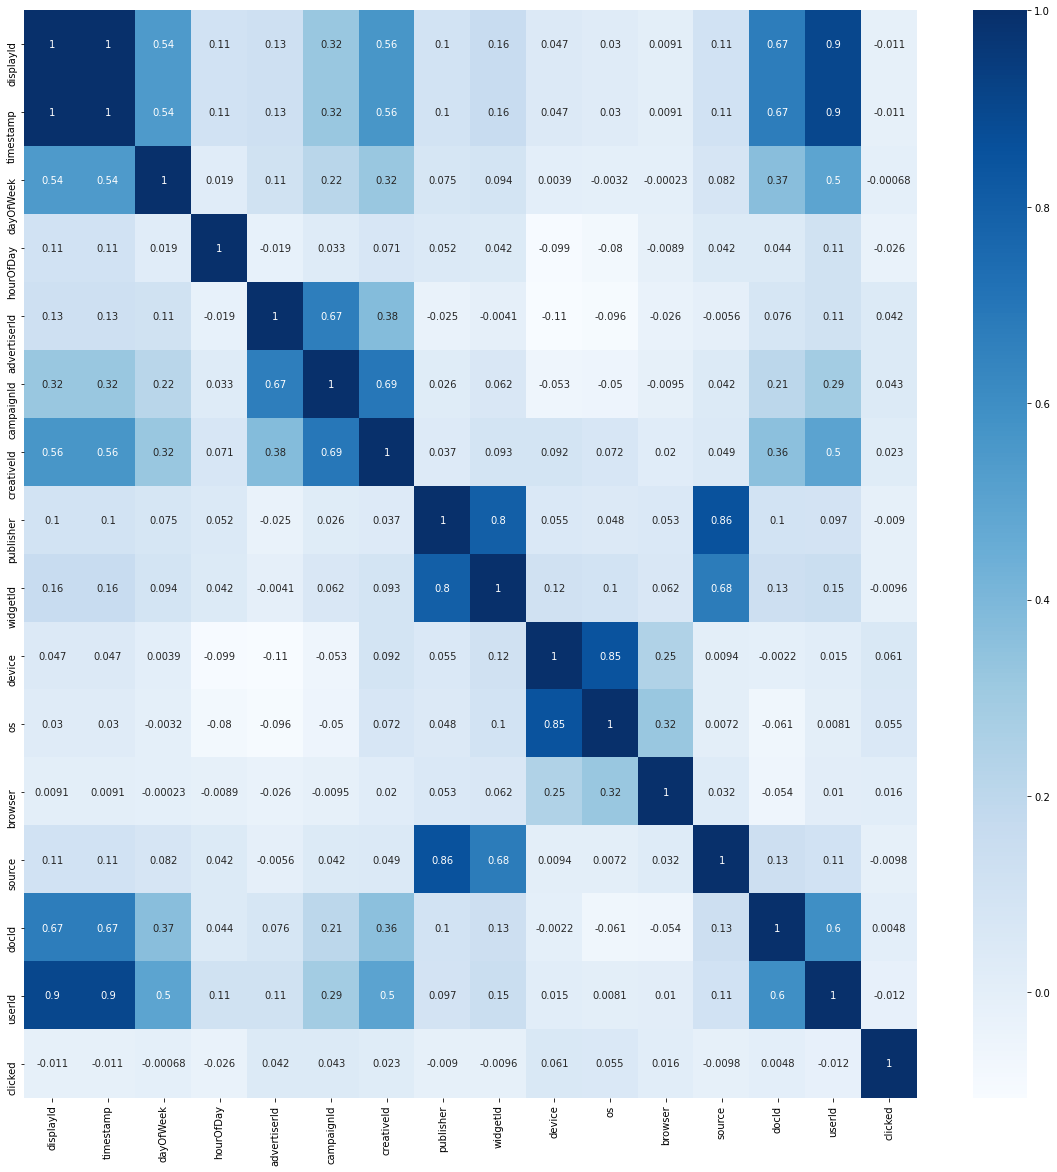

In [ ]:
# 6
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
plt.clf()
fig, ax = plt.subplots(figsize=(20,20))   
# Var_Corr = train.corr()
Var_Corr = train.apply(lambda x : pd.factorize(x)[0]).corr(method='pearson', min_periods=1)
htmp = sns.heatmap(Var_Corr, xticklabels=Var_Corr.columns, yticklabels=Var_Corr.columns, annot=True, ax=ax, cmap=sns.color_palette("Blues", as_cmap=True))
fig = htmp.get_figure()
fig.savefig("heatmap.png")

In [ ]:
from scipy.stats import chisquare

df=train.apply(lambda x : pd.factorize(x)[0])+1

Var_Corr = pd.DataFrame([chisquare(df[x].values,f_exp=df.values.T,axis=1)[0] for x in df])
dfMax = Var_Corr.max(axis=1)
Var_Corr = Var_Corr.divide(dfMax, axis=0)
Var_Corr=(Var_Corr-Var_Corr.mean())/Var_Corr.std()
Var_Corr = Var_Corr.round(2)
htmp = sns.heatmap(Var_Corr, xticklabels=Var_Corr.columns, yticklabels=Var_Corr.columns, annot=True, ax=ax, cmap=sns.color_palette("Blues", as_cmap=True))
fig = htmp.get_figure()
fig.savefig("heatmap3.png")

In [ ]:
# 4
y_train = train['clicked']
train = train.drop('clicked', 1)

<div dir='rtl'>
<font size=5> 
هم‌چنین تست می‌کنیم که برای هر ستون، چند درصد داده‌ی تست در داده‌ی ترین هم هست (چون فیچر کتگوریکال باشد فاصله‌ی عددی اهمیتی ندارد. یعنی اگر فیچر داده‌ی تست عینا در داده‌ی ترین نبوده باشد برای پیش‌بینی به ما کمکی نمی‌کند) که می‌بینیم برای displayId و timestamp اصلا مقادیر داده‌ی تست در داده‌ی ترین موجود نیستند پس منطقی به نظر می‌رسد که این ستونها حذف شوند.
<br><br>
چون کتگوریکال هستند باید همه‌ی آنها را انکد کنیم. برای انکد کردن روش‌های مختلفی وجود دارد. اما با توجه به مقادیر یکتای مختلف در ستون‌ها می‌بینیم که one-hot-encoder برای این کار مناسب نیست چون حافظه‌ی بسیار زیادی نیاز خواهیم داشت. در زیر تعداد مقادیر یکتای هر ستون را می‌بینید:
<br><br>
{'displayId': '842181', 'timestamp': '773941', 'dayOfWeek': '7', 'hourOfDay': '24', 'advertiserId': '200', 'campaignId': '474', 'creativeId': '2696', 'publisher': '759', 'widgetId': '1165', 'device': '4', 'os': '7', 'browser': '75', 'source': '2868', 'docId': '156623', 'userId': '669248'}
<br><br>
بنابراین برای ستون‌هایی مثل displayId، timestamp، docId, userId و بعد از آنها برای source, creativeId و publisher نمی‌توان از one-hot encoding استفاده کرد.

</font>
</div>

In [ ]:
# 5
import math
print(train.describe())
print({a:str(len(train[a].unique())) for a in train.columns})
print(sum([math.log2(len(train[a].unique())) for a in train.columns if not a in ['timestamp', 'displayId', 'source', 'device']]))
print(len(train))

one_hots = ['dayOfWeek', 'hourOfDay', 'device', 'os', 'browser']
big_uniques = ['displayId', 'timestamp', 'docId', 'userId']
middle = list({'advertiserId': '200', 'campaignId': '474', 'creativeId': '2696', 
          'publisher': '759', 'widgetId': '1165', 'source': '2868'}.keys())
print([type(train[a][0]) for a in train.columns])


          displayId     timestamp     dayOfWeek     hourOfDay  advertiserId    campaignId    creativeId     publisher      widgetId        device            os       browser        source         docId        userId
count  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06  3.768416e+06
mean   3.044210e+06  1.579005e+12  2.822654e+00  1.128271e+01  4.851426e+03  4.556158e+03  3.923456e+03  2.463082e+02  7.500866e+03  3.409207e-01  4.306032e-01  1.209916e+00  1.848337e+03  5.065981e+06  1.501631e+06
std    1.019521e+06  3.571385e+08  1.914881e+00  5.618726e+00  2.899004e+03  2.647040e+03  2.482294e+03  5.164171e+02  4.301190e+03  4.817837e-01  6.516009e-01  2.629931e+00  6.529483e+03  3.424284e+06  7.132266e+05
min    1.115095e+06  1.578429e+12  0.000000e+00  0.000000e+00  1.000000e+00  3.000000e+01  6.000000e+00  0.000000e+00  9.000000e+00  0.0

<div dir='rtl'>
<font size=5> 

حال با یک binary encoder فیچرهای باقیمانده را انکد می‌کنیم. این انکدر برای نمایش n مقدار یک ستون به log(n) ستون نیاز دارد (مثلا برای یک ستون ۸ مقداری ۳ستون نیاز دارد که به هر مقدار سه بیت از ۰۰۰ تا ۱۱۱ نسبت می‌دهد) این کار حافظه‌ی لازم برای انکد کردن را کاهش می‌دهد. برای این کار لازم است که از کتابخانه‌ی category_encoders استفاده کنیم.

</font>
</div>

In [ ]:
# 7
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from category_encoders import *
from datetime import datetime

train = train.drop('source', 1)
train = train.drop('displayId', 1)
train = train.drop('device', 1)
train = train.drop('docId', 1)
train = train.drop('userId', 1)
train = train.drop('timestamp', 1)

test = test.drop('source', 1)
test = test.drop('displayId', 1)
test = test.drop('device', 1)
test = test.drop('docId', 1)
test = test.drop('userId', 1)
test = test.drop('timestamp', 1)

old_cols = train.columns
encoder= BinaryEncoder(cols=train.columns,return_df=True)
train = encoder.fit_transform(train)
test = encoder.transform(test)

for col in old_cols:
    train = train.drop(str(col) + "_0", 1)
    test = test.drop(str(col) + "_0", 1)

for col in train.columns:
    if not col in test.columns:
        test[col] = 0

print(train.shape)
print(train.head(10))

print(test.shape)
print(test.head(10))

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm
/usr/local/lib/python3.6/dist-packages/category_encoders/utils.py:21: FutureWarning: is_categorical is deprecated and will be removed in a future version.  Use is_categorical_dtype instead
  elif pd.api.types.is_categorical(cols):


(3768416, 68)
   dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  creativeId_10  creativeId_11  creativeId_12  publisher_1  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  publisher_10  widgetId_1  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9  widgetId_10  widgetId_11  os_1  os_2  os_3  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7
0            0            0            1            0            0            0            0   

In [ ]:
# 8
train = train.reindex(sorted(train.columns), axis=1)
test = test.reindex(sorted(test.columns), axis=1)

print(train.head())
print(test.head())

   advertiserId_1  advertiserId_2  advertiserId_3  advertiserId_4  advertiserId_5  advertiserId_6  advertiserId_7  advertiserId_8  browser_1  browser_2  browser_3  browser_4  browser_5  browser_6  browser_7  campaignId_1  campaignId_2  campaignId_3  campaignId_4  campaignId_5  campaignId_6  campaignId_7  campaignId_8  campaignId_9  creativeId_1  creativeId_10  creativeId_11  creativeId_12  creativeId_2  creativeId_3  creativeId_4  creativeId_5  creativeId_6  creativeId_7  creativeId_8  creativeId_9  dayOfWeek_1  dayOfWeek_2  dayOfWeek_3  hourOfDay_1  hourOfDay_2  hourOfDay_3  hourOfDay_4  hourOfDay_5  os_1  os_2  os_3  publisher_1  publisher_10  publisher_2  publisher_3  publisher_4  publisher_5  publisher_6  publisher_7  publisher_8  publisher_9  widgetId_1  widgetId_10  widgetId_11  widgetId_2  widgetId_3  widgetId_4  widgetId_5  widgetId_6  widgetId_7  widgetId_8  widgetId_9
0               0               0               0               0               0               0            

<div dir='rtl'>
<font size=5> 

هیت‌مپ بعد از انکد شدن داده‌ها
(چون به صفر و یک تبدیل شده‌اند می‌توانیم از کوریلیشن معمولی استفاده کنیم)
</font>
</div>

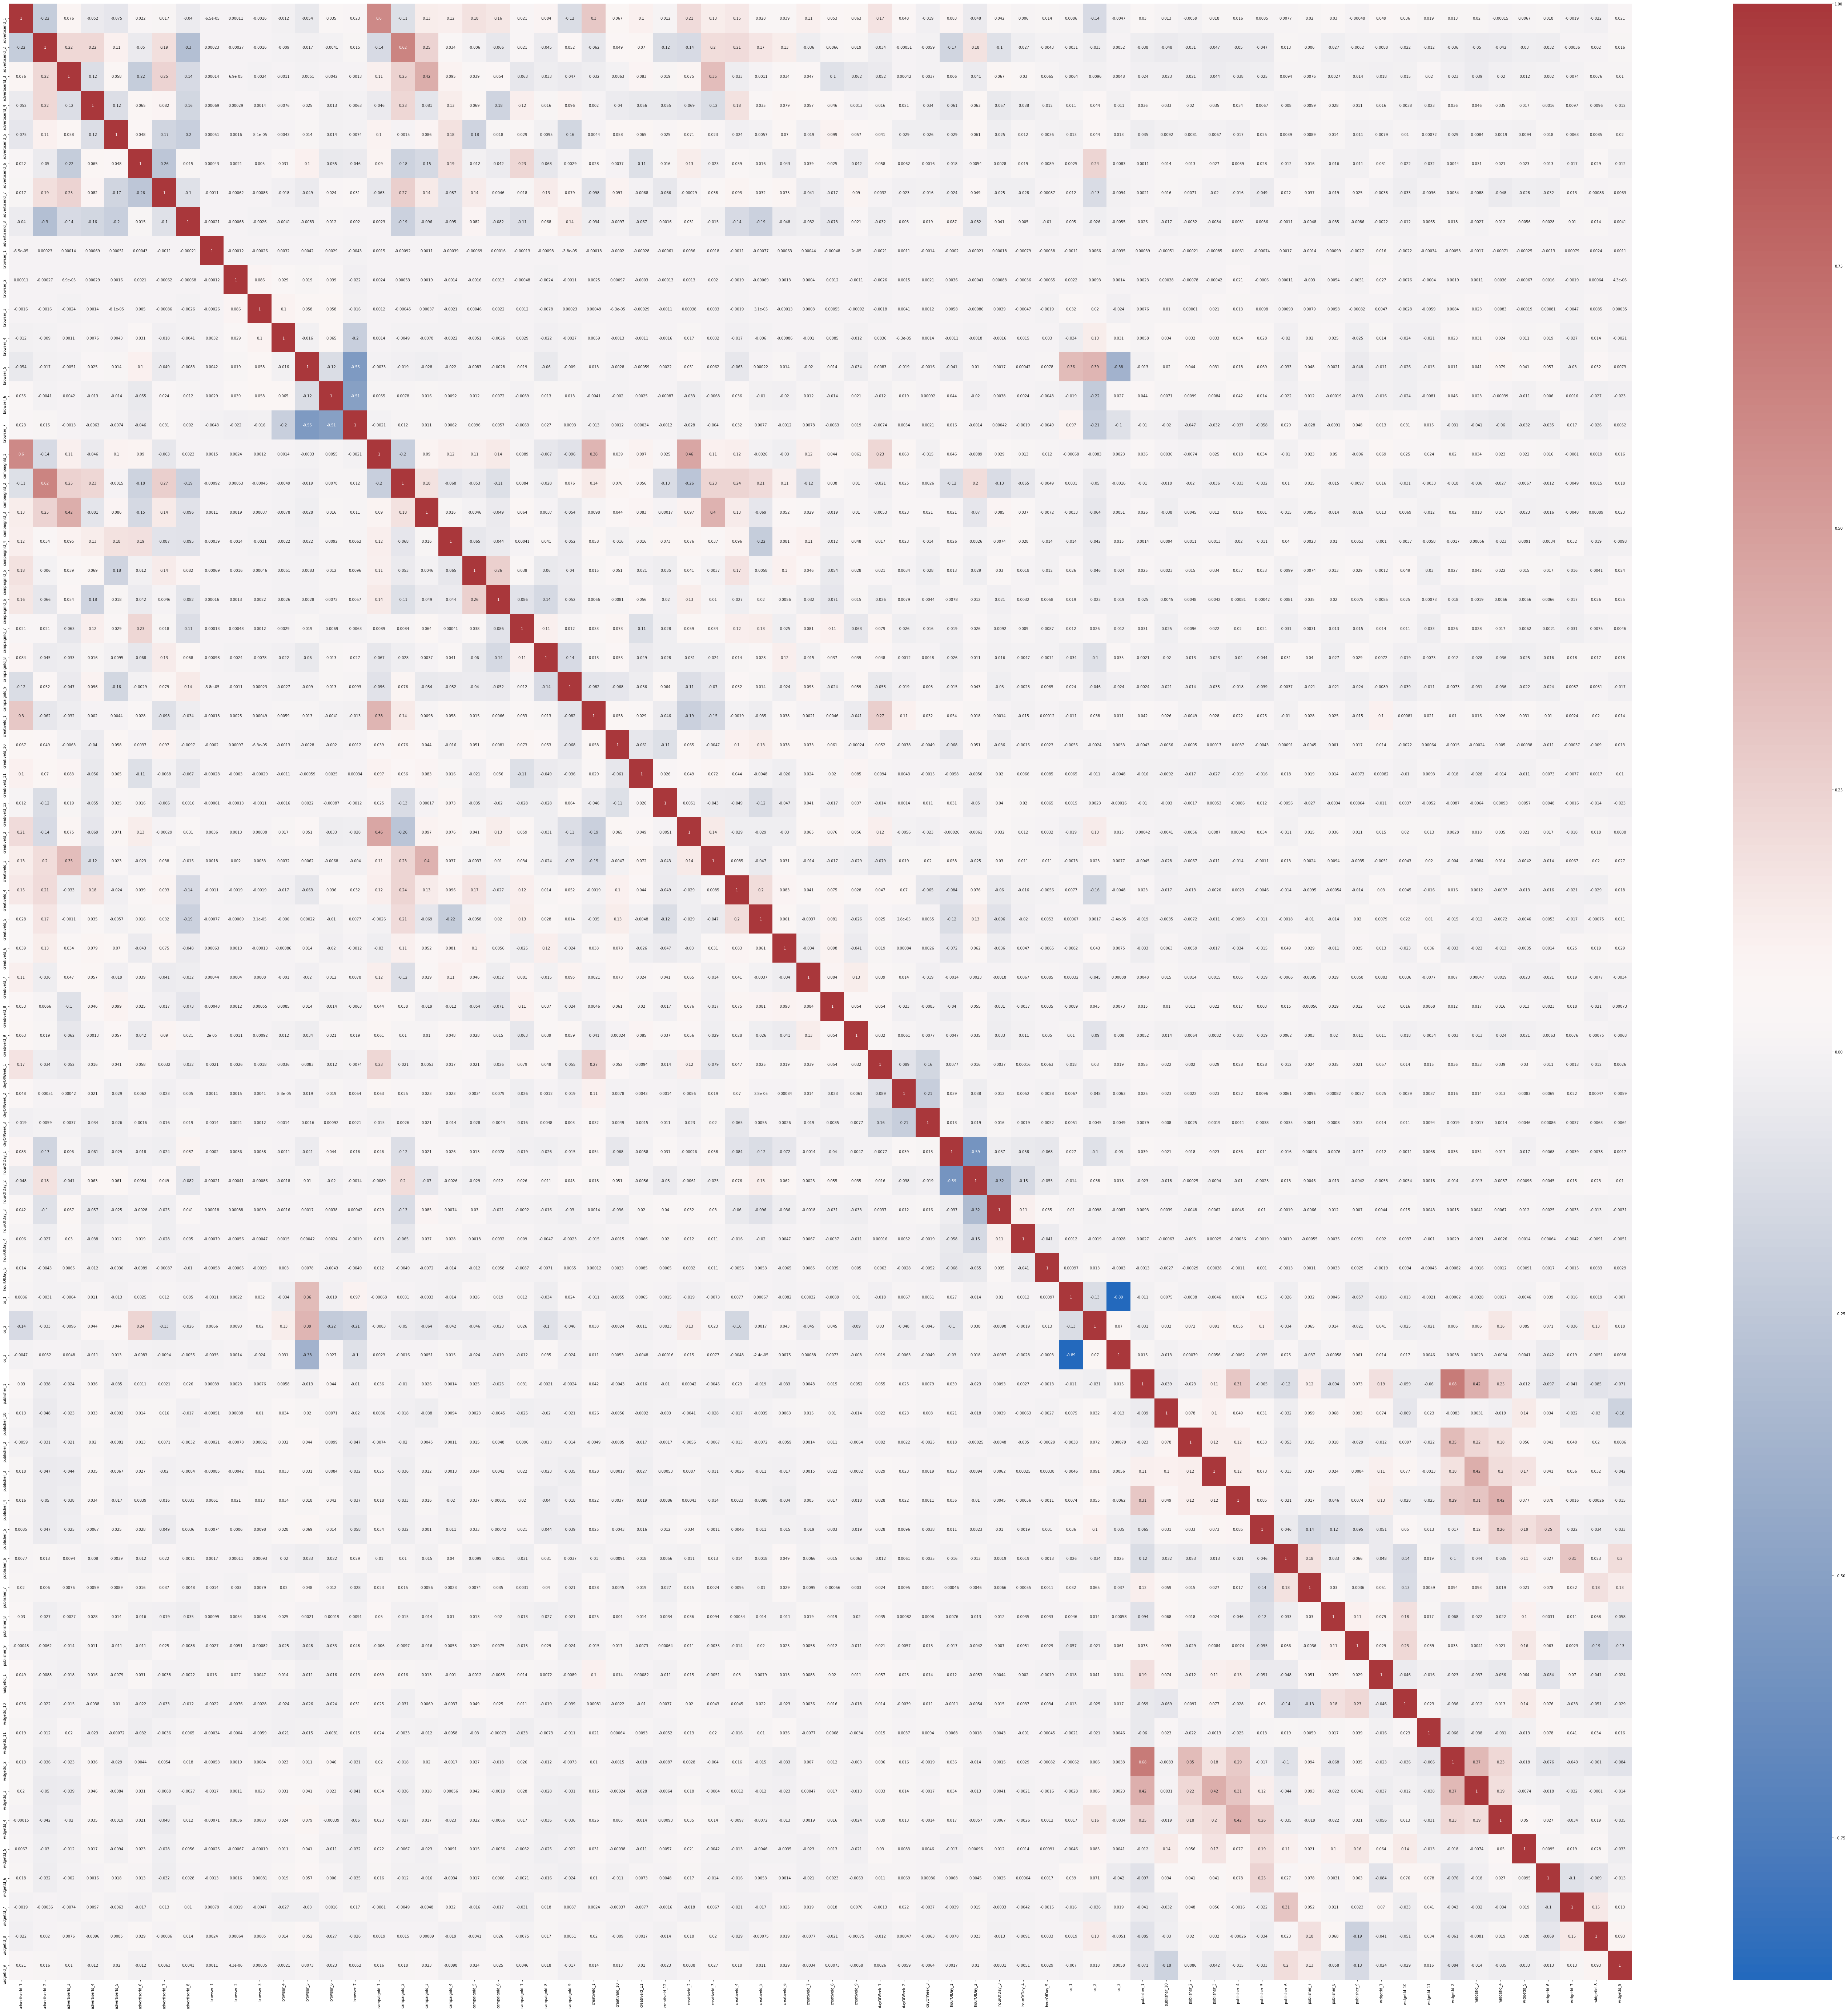

In [ ]:
# 9
fig, ax = plt.subplots(figsize=(100,100))   
Var_Corr = train.corr()
htmp = sns.heatmap(Var_Corr, xticklabels=Var_Corr.columns, yticklabels=Var_Corr.columns, annot=True, ax=ax, cmap=sns.color_palette("vlag", as_cmap=True))
fig = htmp.get_figure()
fig.savefig("heatmap2.png")



<div dir='rtl'>

> Indented block


<font size=5> 
حالا که ستون‌های انکد‌شده را داریم آنهایی که همبستگی‌شان بیشتر از ۰.۷۵ است حذف می‌کنیم

</font>
</div>

In [ ]:
# 10
from math import ceil

def correlation(dataset, test_dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if (abs(corr_matrix.iloc[i, j]) >= threshold) and (corr_matrix.columns[j] not in col_corr):
                colname1 = corr_matrix.columns[i] 
                colname2 = corr_matrix.columns[j] 

                col_corr.add((colname1, colname2, ceil(corr_matrix.iloc[i, j] * 10**3)/ 10**3))
                if colname2 in dataset.columns:
                    del dataset[colname2] # deleting the column from the dataset
                    del test_dataset[colname2]
    return col_corr

c = correlation(train, test, 0.75)
for s in c:
    print(s)

print(train.shape)

('os_3', 'os_1', -0.885)
(3768416, 67)


<div dir='rtl'>
<font size=10> 
انتخاب فیچرها
</font>
</div>

<div dir='rtl'>
<font size=5> 
بعد از آن باید ستون‌های مفیدتر را از بین داده‌مان جدا کنیم. برای این کار سه روش داریم که از سومی استفاده کردیم:
<br><br>
 روش اول: از mutual_information_classifier استفاده می‌کنیم. امتیاز هر ستون را بدست می‌آوریم (امتیاز بیشتر = ستون مفیدتر)

</font>
</div>

Feature 0: 0.006804
Feature 1: 0.075029
Feature 2: 0.057291
Feature 3: 0.108223
Feature 4: 0.106272
Feature 5: 0.107969
Feature 6: 0.115578
Feature 7: 0.088059
Feature 8: 0.000000
Feature 9: 0.000050
Feature 10: 0.000304
Feature 11: 0.001269
Feature 12: 0.016593
Feature 13: 0.011517
Feature 14: 0.182557
Feature 15: 0.035975
Feature 16: 0.079831
Feature 17: 0.056956
Feature 18: 0.099042
Feature 19: 0.107796
Feature 20: 0.107966
Feature 21: 0.145645
Feature 22: 0.138519
Feature 23: 0.113331
Feature 24: 0.006865
Feature 25: 0.118235
Feature 26: 0.104444
Feature 27: 0.108296
Feature 28: 0.037316
Feature 29: 0.064779
Feature 30: 0.091101
Feature 31: 0.104354
Feature 32: 0.120329
Feature 33: 0.118615
Feature 34: 0.114618
Feature 35: 0.119261
Feature 36: 0.147818
Feature 37: 0.127243
Feature 38: 0.135260
Feature 39: 0.047263
Feature 40: 0.115865
Feature 41: 0.122525
Feature 42: 0.118524
Feature 43: 0.112871
Feature 44: 0.065199
Feature 45: 0.210836
Feature 46: 0.000586
Feature 47: 0.072676
Fe

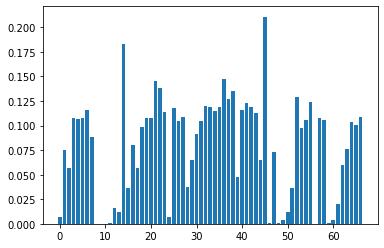

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from matplotlib import pyplot

fs = SelectKBest(score_func=mutual_info_classif, k='all')
fs.fit(train, y_train)
train = fs.transform(train)
test = fs.transform(test)
 

for i in range(len(fs.scores_)):
	print('Feature %d: %f' % (i, fs.scores_[i]))
# plot the scores
pyplot.bar([i for i in range(len(fs.scores_))], fs.scores_)
pyplot.show()

<div dir='rtl'>
<font size=5> 
در نمودار بالا میزان اهمیت هر ستون بر حسب شماره ستون نشان داده شده است.
<br>
مشاهده می‌کنیم که ستون ۴۷ و ۴۴ و ۸ باید حذف شوند. به طور کلی ۳۷ ستونی که کمترین نمره‌ی mutual information را داشتند حذف کردیم.
می‌توانیم ستون‌ها را بر حسب امتیاز mutual information آنها مرتب کنیم
</font>
</div>

<div dir='rtl'>
<font size=5> 

</font>
</div>

In [ ]:
import numpy as np
print(np.argmax(fs.scores_))
s = sorted(range(len(fs.scores_)), key=lambda x: fs.scores_[x])
print([(sp, fs.scores_[sp]) for sp in s[::-1]])
print(fs.scores_[s[len(s) - 37]])
print(np.median(fs.scores_), np.std(fs.scores_))
s1 = [t[0] for t in s]
train = train[:, s1[:30]]
test = test[:, s1[:30]]
train = pd.DataFrame(train)
test = pd.DataFrame(test)
print(pd.DataFrame(train).head())



14
[(14, 0.2072659360052418), (46, 0.12241022176146643), (38, 0.10833975389526662), (37, 0.09923866563444927), (56, 0.09867611185378156), (36, 0.08841806086365667), (42, 0.08407903279999696), (5, 0.08388982670429779), (25, 0.08379643986364838), (66, 0.0835672218013106), (43, 0.08263890192721601), (26, 0.07992797262644791), (22, 0.0785244880660605), (55, 0.07827582094563956), (59, 0.077277250060106), (54, 0.07688950676586415), (58, 0.07675708305139994), (67, 0.07630024607677832), (35, 0.07569457540761926), (21, 0.07473028872807941), (33, 0.0734901180132228), (27, 0.0727635790849257), (23, 0.07223871700776185), (6, 0.06893287361169476), (4, 0.06794582511938474), (20, 0.06745999396578828), (48, 0.0661153763883553), (19, 0.06509723524580946), (32, 0.06504787788963706), (41, 0.0639451748845441), (18, 0.061799701954385), (34, 0.06098834396131925), (65, 0.05358878049087035), (7, 0.05339960988010706), (31, 0.04966544502183101), (3, 0.04832737489047889), (45, 0.04356689744667941), (40, 0.042482

<div dir='rtl'>
<font size=5> 
در روش دوم lasso regression را به کار می‌بریم که یک پاسخ sparse به دست می‌دهد. ضریب هر ویژگی را در نمودار میله‌ای نشان داده‌ایم.
</font>
</div>

<Figure size 432x288 with 0 Axes>

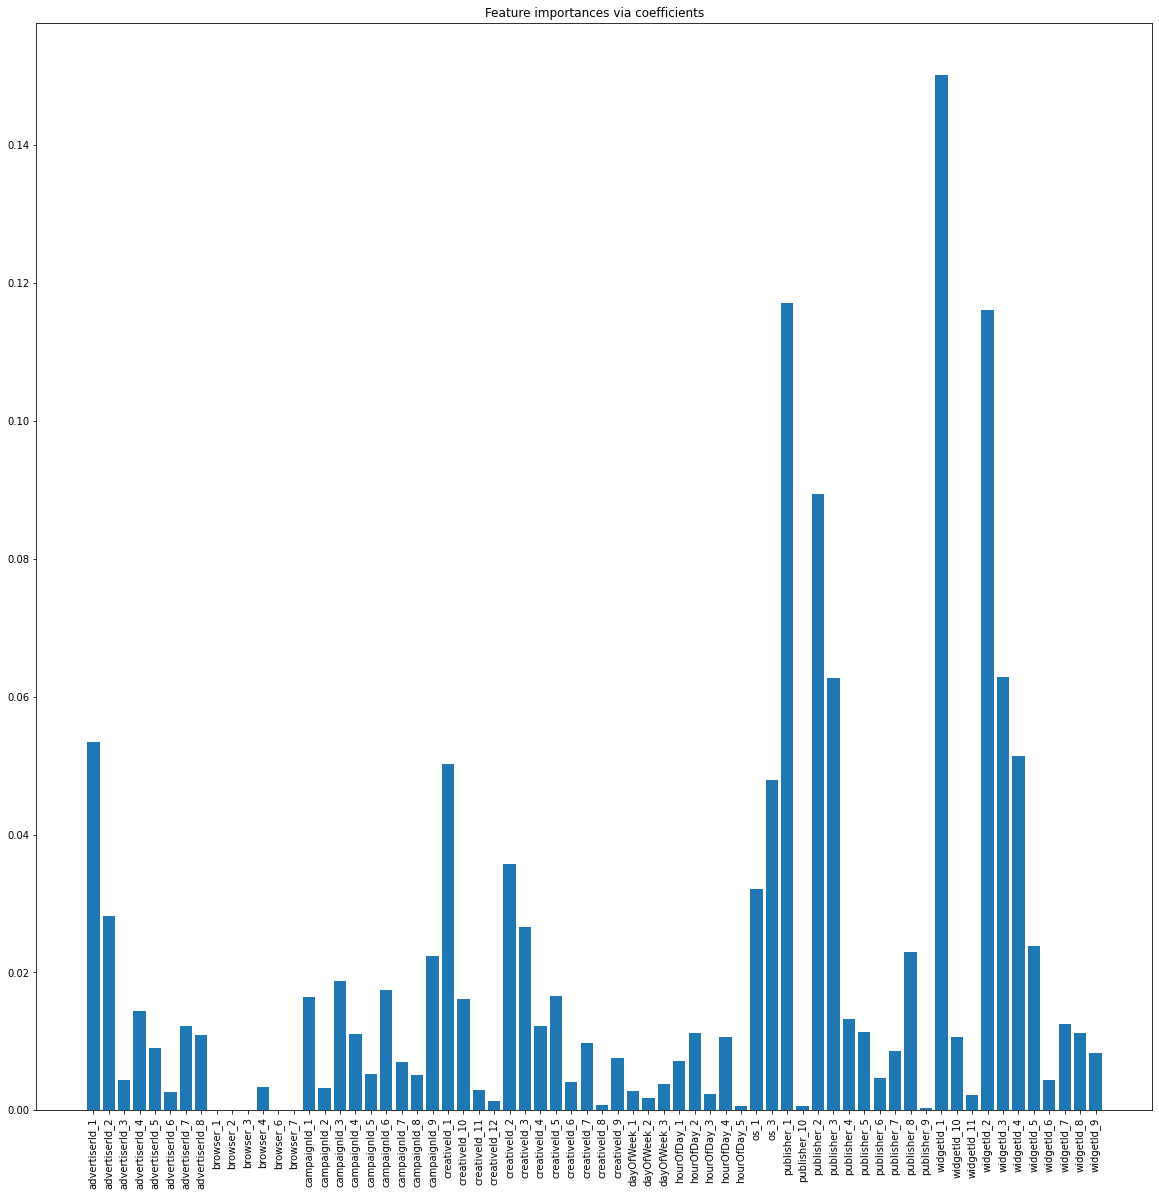

Features selected by SelectFromModel:  ['advertiserId_1' 'advertiserId_2' 'campaignId_9' 'creativeId_1'
 'creativeId_2' 'creativeId_3' 'os_1' 'os_3' 'publisher_1' 'publisher_2'
 'publisher_3' 'publisher_8' 'widgetId_1' 'widgetId_2' 'widgetId_3'
 'widgetId_4' 'widgetId_5']


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LassoCV

from sklearn.feature_selection import SelectFromModel
from time import time

lasso = LassoCV().fit(train, y_train)
importance = np.abs(lasso.coef_)
feature_names = np.array(train.columns)
plt.clf()
f, ax = plt.subplots(figsize=(20, 20))
plt.bar(height=importance, x=feature_names)
plt.title("Feature importances via coefficients")
plt.xticks(rotation=90)
plt.show()


threshold = np.sort(importance)[-1 * int(len(importance)/2)] + 0.01

sfm = SelectFromModel(lasso, threshold=threshold).fit(train, y_train)

print("Features selected by SelectFromModel: ", feature_names[sfm.get_support()])
selected = feature_names[sfm.get_support()]

<div dir='rtl'>
<font size=5>
که مشاهده می‌کنیم که در ۳۰ فیچر اول با روش قبل اشتراک دارد
</font>
</div>

In [ ]:
train = train[selected]
test = test[selected]

<div dir='rtl'>
<font size=5> 

</font>
</div>

<div dir='rtl'>
<font size=5> 

در روش نهایی که عملا استفاده کردیم از selectKbest استفاده می‌کنیم اما برخلا روش اول به جای mutual informaion از معیار chi2 استفاده می‌کنیم که برای داده‌های کتگوریکال به خصوص استفاده می‌شود 
</font>
</div>

In [ ]:
# 11
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2


fs = SelectKBest(score_func=chi2, k=30)
fs.fit(train, y_train)
train = pd.DataFrame(fs.transform(train))
test = pd.DataFrame(fs.transform(test))

print(train.shape)
print(test.shape)

(3768416, 30)
(1072876, 30)


In [ ]:
#randomly removing false data to equlize the ratio of true and false
import numpy as np

false_index = y_train[y_train == 0].index
false_len = len(y_train[y_train == 0])
true_len = len(y_train) - false_len
f2t_rate = int(false_len / true_len)
remove_n = (f2t_rate-1)*true_len

drop_indices = np.random.choice(false_index, remove_n, replace=False)
y = y_train.drop(drop_indices)
X = train.drop(drop_indices).reset_index().drop('index', axis=1)

# روش های برخورد با داده‌های نامتوازن:

<div dir='rtl'>
<font size=5> 

همانطور که می‌دانیم، هنگامی که با داده‌های نامتوان کار می‌کنیم معیار accuracy نمی‌تواند راه‌گشا باشد. برای مثال فرض کنید مدلی داریم که همیشه خروجی صفر می‌هد و توزیع داده ها به صورت ۹۹ درصد ۰ و یک درصد ۱ است. بدیهی است که دقت این مدل ۹۹ درصد است اما به هیچ عنوان توانایی تشخیص ۱ را ندارد که برای ما مناسب نیست. از این رو از معیارهایی مانند recall و f1 استفاده ‌می‌کنیم که دقت مدل در پیش بینی هر کلاس را نشان می‌دهد.

یکی از روش‌های مطرح این است که حساسیت مدل را نسبت به کلاسی که در اقلیت وجود دارد بیشتر کنیم که این کار را با وزن ‌دار کردن مدل‌ها انجام دادیم. در واقع مدل‌ها را نسبت به خطای کلاس اقلیت حساس‌تر کردیم.

روش دیگر oversampling و undersamping است که ما در پیاده سازی‌هایمان از روش undersampling استفاده کرده‌ایم. در روش undersampling تعدادی از داده‌های کلاس اکثریت حذف می‌‌شوند تا نسبت دادهای دو کلاس با یکدیگر برابر شوند.

روش دیگری که برای برخورد با این مساله وجود دارد تولید داده‌های مصنوعی است به طوری که نامتوازن بودن از بین برود مانند الگوریتم‌ smote. هر چند ما از این روش‌ها در پروژه خود استفاده نکرده‌ایم.

</font>
</div>


# تعیین هایپر پارامتر‌ها

<div dir='rtl'>
<font size=5> 

برای تعیین هایپر پارامتر‌ها، به طور کلی از کتابخانه gridsearchcv استفاده کردیم. این کتابخانه به این صورت عمل می‌کند که به عنوان ورودی مدل، داده‌های آموزش، برچسب داده‌های آموزش، روش cross validation، تعداد هسته‌های پردازنده که قرار است برای پردازش از آنها استفاده شود و پارامتر‌هایی از مدل که می‌خواهیم بهترین آنها را پیدا کنیم را می‌گیرد. سپس مدل را با تمامی حالاتی که در قسمت پارامتر‌های متغیر تعیین شده تست می‌کند و با توجه به روش ارزیابی که برای آن مشخص کرده‌ایم (ما در مدل‌ها از AUC استفاده کردیم) بهترین پارامترها را انتخاب می‌کند.
اما با توجه به اینکه در بعضی از مدل‌ها تعداد پارامتر‌ها خیلی زیاد بود مجبور شدیم که به صورت مرحله به مرحله پارامتر‌ها را بهتر کنیم چون درغیر اینصورت زمان اجرا خیلی طول می‌کشید و نمی‌شد به خروجی دست یافت. به همین منظور از این امکان که می‌توان چندین پارامتر داد استفاده نکردیم یا به صورت خیلی محدود استفاده شد.


</font>
</div>


# تقسیم دادگان به آموزش، ارزیابی وآزمایش


<div dir='rtl'>
<font size=5> 


همانطور که در بالا اشاره شد، gridsearchcv این قابلیت را دارد که برای آن نحوه‌ی crossvalidation نیز مشخص بشود. ما برای مدل‌ها از روش RepeatedStratifiedKFold استفاده کردیم. در این روش می‌توان تعداد دفعات تکرار cross validation را مشخص کرد و مشخص کرد که چه قسمی از دادگان را برای cross validation بردارد. این روش با kfold عادی این تفاوت را دارد که در هر split نسبت کلاس ۱ و ۰ حدودا با نسبت آنها در کل حدودا یکی است.

</font>
</div>


#روش‌های ارزیابی

##AUC



<div dir='rtl'>
<font size=5> 



این معیار درواقع مساحت زیر نمودار ROC را نشان می‌دهد. ROC نموداری است که دو پارارمتر دارد، نرخ True Positive و نرخ False Positive. این نمودار TP vs FP را برای حدود‌(threshold)های مختلف classification رسم‌ می‌کند. پایین اورد این حد باعث می‌شود که موارد بیشتری به عنوان positive تلقی شوند پس نرخ TP و FP هر دو افزایش می‌یابد. حال AUC یک تجمیع از تمامی حالات مختلف دسته‌بندی ارایه می‌دهد. یک روش برای تفسیر AUC می‌تواند این‌گونه باشد که مدل چقدر می‌تواند بین کلاس‌های مختلف تفاوت قائل شود. پس هر چه این مقدار بیشتر باشد ۰ ها بیشتر ۰ پیشبینی می‌شوند و همینطور ۱‌ها هم بیشتر ۱ پیشبینی خواهند شد.

</font>
</div>


##cross entropy



<div dir='rtl'>
<font size=5> 


این معیاری عملکرد مدل دسته‌بند را اندازه‌گیری می‌کند که خروجی آن مقداری بین ۰ و یک است. هرچقدر احتمال پیشبینی شده با برچسب داده مورد نظر از همدیگر دور باشند، مقدار loss  بیشتر خواهد شد. این معیار برای دسته‌بند دو کلاسه از طریق زیر محاسبه می‌شود:
-(ylog(p) + (1-y)log(1-p))


</font>
</div>


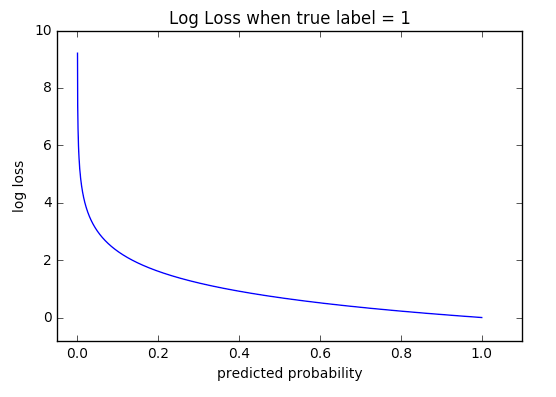



<div dir='rtl'>
<font size=5> 

شکل بالا مقادیر ممکن خطا برای یک مشاهده صحیح را نشان می‌دهد (isDog==1). همانطور که احتمال پیشبینی شده به سمت ۱ میل می‌کند مقدار خطا نیز کاهش می‌یابد.

</font>
</div>



##F1




<div dir='rtl'>
<font size=5> 



این معیار میانگینی از معیار‌های precision و recall است که بترتیب تعداد TP در بین کل دادها و دادهای positive محاسبه می‌کنند. در واقع این معیار بیان‌ می‌کند که مدل در عین اینکه هر کلاس را چقدر خوب دسته‌بندی می‌کند عملکرد آن به طور کلی نیز چگونه است. این معیار از طریق رابطه‌ی زیر بدست‌ میآید:

$\frac{2tp}{2tp + fp + fn}$


</font>
</div>



#MODELS

##XGBoost




<div dir='rtl'>
<font size=5> 


این روش یکی از روش‌های بهینه stochastic gradient boosting  است که پارامتر‌های زیادی برای کنترل مدل ارائه می‌کند. برای اینکه این مدل بتواند با دادهای نامتوازن برخورد کند ما از مدل وزن‌دار آن استفاده کردیم. این مدل پارمتری بنام scale_pos_weight دارد که طراحی شده تا رفتار الگوریتم را برای دسته‌بند‌ی‌های نامتوازن بهینه کند. این پارامتر برای مقیاس کردن gradient کلاس ۱(که همان کلاس اقلیت در مساله‌ ماست) طراحی شده‌است و هر چه مقدار آن بیشتر باشه در صورت وجود خطا در کلاس اقلیت گرادیانت بیشتر تاثیر خواهد داشت (در آپدیت کردن پارامترها).
یکی دیگر از عواملی که روی عملکرد مدل تاثیر می‌گذارد عمق درختان است که ما این مورد را حداکثر برابر ۷ درنظر گرفتیم. بدیهی است که هر چه این مقدار بیشتر باشد عملکرد مدل روی داده‌های آموزش بهتر خواهد بود. این مقدار به طور معمول بین ۱ الی ۱۰ است. و با توجه به اینکه مقادیر ۱۰ و یا حتی بالاتر تفاوت چندانی با ۷ نداشتند، ما این عدد را به عنوان پارامتر انتخاب کردیم.
در چند مدلی که آموزش دادیم، scale_pos_weight را از حدود نسبت دو کلاس درنظر گرفتیم و بترتیب زیاد کردیم اما بهترین عملکرد زمانی دیده شد که این پارامتر برابر با نسبت کلاس اکثریت به اقلیت باشد.
البته در یک مورد داده‌های اصلی را بدون undersampling به صورت وزن دار آموزش دادیم که نتایج آنها نیز با سایر حالات تفاوت خاصی نداشت.

</font>
</div>




###aproach 1

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

filename = project_dir + 'xgb1.pkl'
scale_pos_weight = [1.2] #np.arange(0.5, 4, 0.3)
max_depth = [7]
learning_rate = [0.01]

param_grid = dict(scale_pos_weight=scale_pos_weight,
                  max_depth=max_depth,
                  learning_rate = learning_rate)

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

xgb = GridSearchCV(estimator=XGBClassifier(n_estimators=100),
                    param_grid=param_grid,
                    n_jobs=-1,
                    cv=cv,
                    scoring='roc_auc')

xgb_result = xgb.fit(X, y)
joblib.dump(xgb, filename)

CONFUSION MATRIX
[[0.62981422 0.14670169]
 [0.1545124  0.06897168]]
              precision    recall  f1-score   support

           0       0.80      0.81      0.81   2926235
           1       0.32      0.31      0.31    842181

    accuracy                           0.70   3768416
   macro avg       0.56      0.56      0.56   3768416
weighted avg       0.70      0.70      0.70   3768416

AUC:
0.5598485754552772
CROSS-ENTROPY:
0.6470821867238211


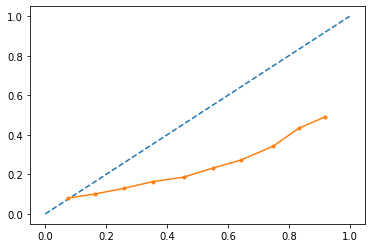

In [ ]:
# load your model for further usage
import joblib
filename = project_dir + 'xgb1.pkl'

xgb = joblib.load(filename)

prob_xgb_train = xgb.predict_proba(train)
pred_xgb_train = xgb.predict(train)
score(y_train, pred_xgb_train, prob_xgb_train)
reliability_diagram(prob_xgb_train[:, 1])

###aproach 2

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

scale_pos_weight = [2] #np.arange(0.5, 4, 0.3)
max_depth = [7]
learning_rate = [0.01] #np.arange(0.001, 0.01, 0.001)
filename = project_dir + 'xgb2.pkl'

param_grid = dict(scale_pos_weight=scale_pos_weight,
                  max_depth=max_depth,
                  learning_rate = learning_rate)

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

xgb = GridSearchCV(estimator=XGBClassifier(n_estimators=10),
                    param_grid=param_grid,
                    n_jobs=-1,
                    cv=cv,
                    scoring='roc_auc')

xgb_result = xgb.fit(X, y)
joblib.dump(xgb, filename)

['/content/drive/MyDrive/ML_Project/xgb2.pkl']

CONFUSION MATRIX
[[0.17487347 0.60164244]
 [0.02916185 0.19432223]]
              precision    recall  f1-score   support

           0       0.86      0.23      0.36   2926235
           1       0.24      0.87      0.38    842181

    accuracy                           0.37   3768416
   macro avg       0.55      0.55      0.37   3768416
weighted avg       0.72      0.37      0.36   3768416

AUC:
0.5473576514531012
CROSS-ENTROPY:
0.6986589008983702


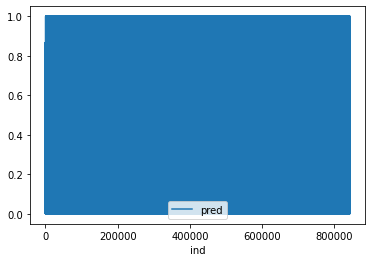

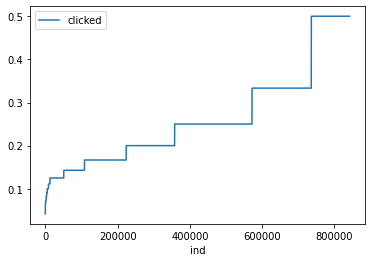

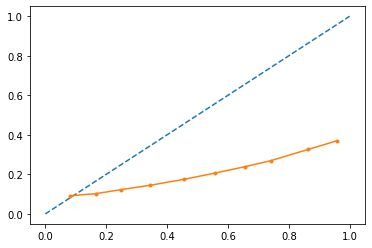

In [ ]:
import joblib
filename = project_dir + 'xgb2.pkl'
xgb = joblib.load(filename)

prob_xgb_train = xgb.predict_proba(train)
pred_xgb_train = xgb.predict(train)

score(y_train, pred_xgb_train, prob_xgb_train)
plot(pred_xgb_train)
reliability_diagram(prob_xgb_train[:, 1])

###aproach 3

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

scale_pos_weight = [4] #np.arange(0.5, 4, 0.3)
max_depth = [7]
learning_rate = [0.01] #np.arange(0.001, 0.01, 0.001)
filename = project_dir + 'xgb3.pkl'

param_grid = dict(scale_pos_weight=scale_pos_weight,
                  max_depth=max_depth,
                  learning_rate = learning_rate)

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

xgb = GridSearchCV(estimator=XGBClassifier(n_estimators=10),
                    param_grid=param_grid,
                    n_jobs=-1,
                    cv=cv,
                    scoring='roc_auc')

xgb_result = xgb.fit(X, y)
joblib.dump(xgb, filename)

['/content/drive/MyDrive/ML_Project/xgb3.pkl']

CONFUSION MATRIX
[[3.32580055e-03 7.73190115e-01]
 [3.35419444e-04 2.23148665e-01]]
              precision    recall  f1-score   support

           0       0.91      0.00      0.01   2926235
           1       0.22      1.00      0.37    842181

    accuracy                           0.23   3768416
   macro avg       0.57      0.50      0.19   3768416
weighted avg       0.76      0.23      0.09   3768416

AUC:
0.5013910564701817
CROSS-ENTROPY:
0.7159404882650191


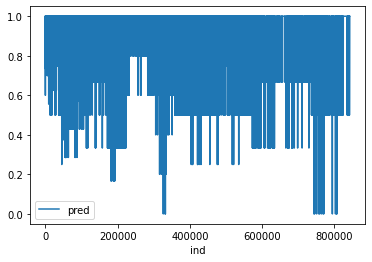

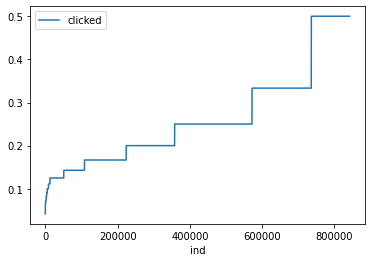

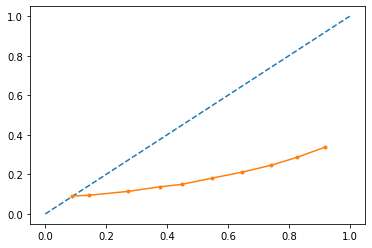

In [ ]:
import joblib
filename = project_dir + 'xgb3.pkl'
xgb = joblib.load(filename)

pred_xgb_train = xgb.predict(train)
prob_xgb_train = xgb.predict_proba(train)

score(y_train, pred_xgb_train, prob_xgb_train)
plot(pred_xgb_train)
reliability_diagram(prob_xgb_train[:, 1])

###aproach 4

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

filename = project_dir + 'xgb4.pkl'
scale_pos_weight = [2, 2.5, 3]
max_depth = [5]
learning_rate = [0.01]

param_grid = dict(scale_pos_weight=scale_pos_weight,
                  max_depth=max_depth,
                  learning_rate = learning_rate)

cv = RepeatedStratifiedKFold(n_splits=10,
                             n_repeats=1,
                             random_state=1)

xgb = GridSearchCV(estimator=XGBClassifier(n_estimators=100),
                    param_grid=param_grid,
                    n_jobs=-1,
                    cv=cv,
                    scoring='roc_auc')

xgb_result = xgb.fit(X, y)
joblib.dump(xgb, filename)

['/content/drive/MyDrive/ML_Project/xgb4.pkl']

CONFUSION MATRIX
[[0.13253712 0.6439788 ]
 [0.02201376 0.20147033]]
              precision    recall  f1-score   support

           0       0.86      0.17      0.28   2926235
           1       0.24      0.90      0.38    842181

    accuracy                           0.33   3768416
   macro avg       0.55      0.54      0.33   3768416
weighted avg       0.72      0.33      0.31   3768416

AUC:
0.536089601044416
CROSS-ENTROPY:
0.7406621969803535


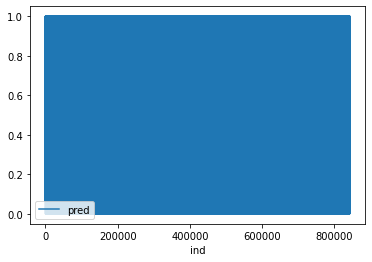

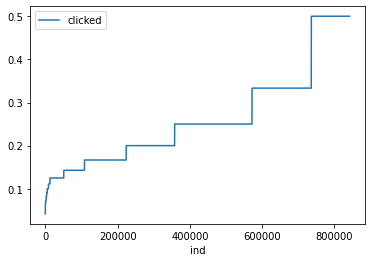

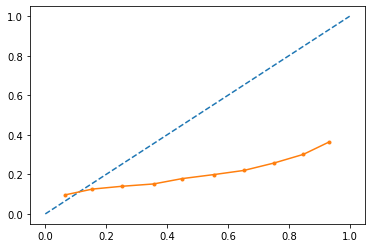

In [ ]:
import joblib
filename = project_dir + 'xgb4.pkl'
xgb = joblib.load(filename)

pred_xgb_train = xgb.predict(train)
prob_xgb_train = xgb.predict_proba(train)

score(y_train, pred_xgb_train, prob_xgb_train)
plot(pred_xgb_train)
reliability_diagram(prob_xgb_train[:, 1])

###aproach 5

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.datasets import make_classification
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import log_loss
from xgboost import XGBClassifier
import joblib

rate = len(y_train[y_train==0])/len(y_train[y_train==1])
scale_pos_weight = [rate]
max_depth = [7]
learning_rate = [0.01]

filename = project_dir + 'xgb5.pkl'

param_grid = dict(scale_pos_weight=scale_pos_weight,
                  max_depth=max_depth,
                  learning_rate = learning_rate)

cv = RepeatedStratifiedKFold(n_splits=3,
                             n_repeats=1,
                             random_state=1)

xgb = GridSearchCV(estimator=XGBClassifier(n_estimators=20),
                    param_grid=param_grid,
                    n_jobs=-1,
                    cv=cv,
                    scoring='roc_auc')

xgb_result = xgb.fit(train, y_train)
joblib.dump(xgb, filename)

['/content/drive/MyDrive/ML_Project/xgb5.pkl']

CONFUSION MATRIX
[[0.39398463 0.38253128]
 [0.08352661 0.13995748]]
              precision    recall  f1-score   support

           0       0.83      0.51      0.63   2926235
           1       0.27      0.63      0.38    842181

    accuracy                           0.53   3768416
   macro avg       0.55      0.57      0.50   3768416
weighted avg       0.70      0.53      0.57   3768416

AUC:
0.5668136931549633
CROSS-ENTROPY:
0.6887806609687549


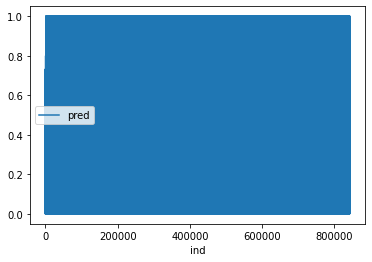

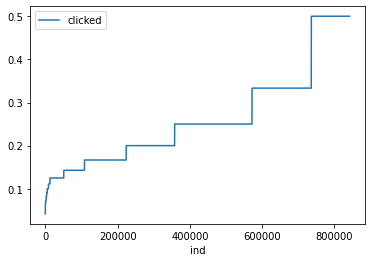

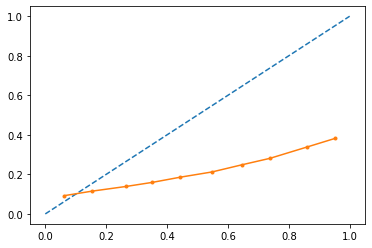

In [ ]:
import joblib
filename = project_dir + 'xgb5.pkl'
xgb = joblib.load(filename)

pred_xgb_train = xgb.predict(train)
prob_xgb_train = xgb.predict_proba(train)


score(y_train, pred_xgb_train, prob_xgb_train)
plot(pred_xgb_train)
reliability_diagram(prob_xgb_train[:, 1])

با توجه به مدل ‌های بالا بهتریت مدل هنگامی است که scale_pos_weight برابر نسبت دو کلاس باشد. پس ما از این مدل برای پیشبینی داده های تست استفاده می‌کنیم:

In [ ]:
import joblib
filename = project_dir + 'xgb5.pkl'
xgb = joblib.load(filename)

pred_xgb_test = xgb.predict(test)
prob_xgb_test = xgb.predict_proba(test)

joblib.dump(pred_xgb_test, project_dir+'xgb_test_pred.pkl')
joblib.dump(prob_xgb_test, project_dir+'xgb_test_probs.pkl')

['/content/drive/MyDrive/ML_Project/xgb_test_probs.pkl']